In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os, random, math, warnings, gc
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
print(f'GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4


In [3]:
class CFG:
    data_dir     = Path('/kaggle/input/competitions/plant-leaves-super-resolution-challenge')
    train_hr_dir = data_dir / 'train_High_Resolution'
    train_lr_dir = data_dir / 'train_Low_Resolution'
    test_lr_dir  = data_dir / 'test_Low_Resolution'
    vgg_weights  = data_dir / 'vgg19_weights.pth'
    output_dir   = Path('/kaggle/working')
    gen_ckpt_p1  = output_dir / 'generator_phase1.pth'   
    gen_ckpt_p2  = output_dir / 'generator_phase2.pth'   

    lr_size      = 32
    hr_size      = 128
    scale_factor = 4
    n_channels   = 3

    g_base_ch    = 64
    n_rrdb       = 23          
    growth_ch    = 32

    d_base_ch    = 64
    n_d_scales   = 3           

    seed         = 42
    batch_size   = 16
    num_workers  = 2
    amp          = True

    p1_epochs    = 100
    p1_g_lr      = 2e-4
    p1_lambda_l1   = 1.0
    p1_lambda_perc = 0.01      
    p1_warmup    = 5
    p1_eta_min   = 1e-6

    p2_epochs    = 60
    p2_g_lr      = 5e-5        
    p2_d_lr      = 1e-4
    p2_lambda_l1   = 1.0
    p2_lambda_perc = 0.05
    p2_lambda_adv  = 0.005     
    p2_lambda_fm   = 0.1       
    p2_n_d_steps = 1           
    p2_warmup    = 3
    p2_eta_min   = 1e-7
    beta1        = 0.9
    beta2        = 0.999
    weight_decay = 1e-4
    grad_clip    = 1.0

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CFG.output_dir.mkdir(exist_ok=True)

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = True

seed_everything(CFG.seed)
print('Config ready.  Device:', CFG.device)

Config ready.  Device: cuda


In [4]:
class SRDataset(Dataset):
    def __init__(self, lr_paths, hr_paths=None, augment=False):
        self.lr_paths = lr_paths
        self.hr_paths = hr_paths
        self.augment  = augment

    def __len__(self):
        return len(self.lr_paths)

    @staticmethod
    def _to_tensor(img_np):
        return torch.from_numpy(img_np.transpose(2, 0, 1)).float() / 255.0

    def __getitem__(self, idx):
        lr = np.array(Image.open(self.lr_paths[idx]).convert('RGB'))

        if self.hr_paths is not None:
            hr = np.array(Image.open(self.hr_paths[idx]).convert('RGB'))

            if self.augment:
                if random.random() > 0.5:
                    lr = lr[:, ::-1, :].copy(); hr = hr[:, ::-1, :].copy()
                if random.random() > 0.5:
                    lr = lr[::-1, :, :].copy(); hr = hr[::-1, :, :].copy()
                k = random.randint(0, 3)
                if k > 0:
                    lr = np.rot90(lr, k).copy(); hr = np.rot90(hr, k).copy()
                # mild colour jitter
                if random.random() > 0.6:
                    alpha = random.uniform(0.9, 1.1)
                    beta  = random.uniform(-8, 8)
                    lr = np.clip(lr.astype(np.float32)*alpha + beta, 0, 255).astype(np.uint8)
                    hr = np.clip(hr.astype(np.float32)*alpha + beta, 0, 255).astype(np.uint8)

            return self._to_tensor(lr), self._to_tensor(hr)

        fname = Path(self.lr_paths[idx]).name
        return self._to_tensor(lr), fname


lr_files = sorted(CFG.train_lr_dir.glob('*.png'))
hr_files = sorted(CFG.train_hr_dir.glob('*.png'))
assert len(lr_files) == len(hr_files)
tst_lr   = sorted(CFG.test_lr_dir.glob('*.png'))


trn_ds  = SRDataset(list(lr_files), list(hr_files), augment=True)
mon_ds  = SRDataset(list(lr_files)[:80], list(hr_files)[:80], augment=False)  # monitoring only
tst_ds  = SRDataset(tst_lr, augment=False)

trn_loader = DataLoader(trn_ds, batch_size=CFG.batch_size, shuffle=True,
                        num_workers=CFG.num_workers, pin_memory=True, drop_last=True)
mon_loader = DataLoader(mon_ds, batch_size=32, shuffle=False,
                        num_workers=CFG.num_workers, pin_memory=True)
tst_loader = DataLoader(tst_ds, batch_size=32, shuffle=False,
                        num_workers=CFG.num_workers, pin_memory=False)

print(f'Train : {len(trn_ds):,}  |  Monitor : {len(mon_ds):,}  |  Test : {len(tst_ds):,}')

Train : 1,642  |  Monitor : 80  |  Test : 495


In [5]:
class DenseBlock(nn.Module):
    def __init__(self, n_feat, growth_ch=32, beta=0.2):
        super().__init__()
        self.beta = beta
        in_ch = n_feat
        layers = []
        for i in range(5):
            out_ch = growth_ch if i < 4 else n_feat
            layers.append(nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, 1, 1, bias=True),
                nn.LeakyReLU(0.2, inplace=True) if i < 4 else nn.Identity()
            ))
            in_ch += growth_ch if i < 4 else 0
        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        inputs = [x]
        for i, layer in enumerate(self.layers):
            out = layer(torch.cat(inputs, dim=1))
            if i < 4:
                inputs.append(out)
            else:
                feat = out
        return x + self.beta * feat


class RRDB(nn.Module):
    def __init__(self, n_feat, growth_ch=32, beta=0.2):
        super().__init__()
        self.beta = beta
        self.rdb1 = DenseBlock(n_feat, growth_ch, beta)
        self.rdb2 = DenseBlock(n_feat, growth_ch, beta)
        self.rdb3 = DenseBlock(n_feat, growth_ch, beta)

    def forward(self, x):
        return x + self.beta * self.rdb3(self.rdb2(self.rdb1(x)))


class Generator(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, n_feat=64, n_rrdb=23, growth_ch=32):
        super().__init__()
        self.conv_in    = nn.Conv2d(in_ch, n_feat, 3, 1, 1, bias=True)
        self.trunk      = nn.Sequential(*[RRDB(n_feat, growth_ch) for _ in range(n_rrdb)])
        self.conv_trunk = nn.Conv2d(n_feat, n_feat, 3, 1, 1, bias=True)
        self.upsample   = nn.Sequential(
            nn.Conv2d(n_feat, n_feat*4, 3, 1, 1, bias=True), nn.PixelShuffle(2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(n_feat, n_feat*4, 3, 1, 1, bias=True), nn.PixelShuffle(2),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.conv_hr  = nn.Sequential(
            nn.Conv2d(n_feat, n_feat, 3, 1, 1, bias=True), nn.LeakyReLU(0.2, inplace=True)
        )
        self.conv_out = nn.Conv2d(n_feat, out_ch, 3, 1, 1, bias=True)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, a=0.2, mode='fan_in',
                                        nonlinearity='leaky_relu')
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, lr):
        feat  = self.conv_in(lr)
        feat  = feat + self.conv_trunk(self.trunk(feat))
        feat  = self.upsample(feat)
        return torch.clamp(self.conv_out(self.conv_hr(feat)), 0.0, 1.0)


G = Generator(
    in_ch=CFG.n_channels, out_ch=CFG.n_channels,
    n_feat=CFG.g_base_ch, n_rrdb=CFG.n_rrdb, growth_ch=CFG.growth_ch
).to(CFG.device)

print(f'Generator params: {sum(p.numel() for p in G.parameters() if p.requires_grad)/1e6:.2f} M')

Generator params: 16.92 M


In [6]:
class SingleScaleD(nn.Module):
    def __init__(self, in_ch=6, base_ch=64):
        super().__init__()
        def block(ic, oc, stride=2, norm=True):
            layers = [nn.utils.spectral_norm(nn.Conv2d(ic, oc, 4, stride, 1, bias=False))]
            if norm: layers.append(nn.InstanceNorm2d(oc, affine=True))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return nn.Sequential(*layers)

        self.b0 = block(in_ch,      base_ch,   stride=2, norm=False)
        self.b1 = block(base_ch,    base_ch*2, stride=2)
        self.b2 = block(base_ch*2,  base_ch*4, stride=2)
        self.b3 = block(base_ch*4,  base_ch*8, stride=1)
        self.head = nn.utils.spectral_norm(
            nn.Conv2d(base_ch*8, 1, 4, 1, 1, bias=False)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, 0.0, 0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, lr_up, hr):
        x  = torch.cat([lr_up, hr], dim=1)
        f0 = self.b0(x)
        f1 = self.b1(f0)
        f2 = self.b2(f1)
        f3 = self.b3(f2)
        logits   = self.head(f3)
        features = [f0, f1, f2, f3]   # for feature matching loss
        return logits, features


class MultiScaleDiscriminator(nn.Module):
    def __init__(self, in_ch=6, base_ch=64, n_scales=3):
        super().__init__()
        self.discriminators = nn.ModuleList(
            [SingleScaleD(in_ch, base_ch) for _ in range(n_scales)]
        )
        self.downsample = nn.AvgPool2d(kernel_size=3, stride=2, padding=1)

    def forward(self, lr_up, hr):
        logits_list, feats_list = [], []
        for disc in self.discriminators:
            logits, feats = disc(lr_up, hr)
            logits_list.append(logits)
            feats_list.append(feats)
            # downsample both inputs for the next scale
            lr_up = self.downsample(lr_up)
            hr    = self.downsample(hr)
        return logits_list, feats_list


D = MultiScaleDiscriminator(
    in_ch=CFG.n_channels*2, base_ch=CFG.d_base_ch, n_scales=CFG.n_d_scales
).to(CFG.device)

print(f'Multi-scale D params: {sum(p.numel() for p in D.parameters() if p.requires_grad)/1e6:.2f} M')

Multi-scale D params: 8.31 M


In [7]:
import torchvision.models as tv_models

class VGGPerceptualLoss(nn.Module):
    def __init__(self, vgg_weights_path, device):
        super().__init__()
        vgg   = tv_models.vgg19(pretrained=False)
        state = torch.load(vgg_weights_path, map_location=device)
        vgg.load_state_dict(state)
        self.feat = nn.Sequential(*list(vgg.features.children())[:18]).to(device).eval()
        for p in self.feat.parameters(): p.requires_grad = False
        mean = torch.tensor([0.485,0.456,0.406], device=device).view(1,3,1,1)
        std  = torch.tensor([0.229,0.224,0.225], device=device).view(1,3,1,1)
        self.register_buffer('mean', mean)
        self.register_buffer('std',  std)

    @torch.no_grad()
    def _f(self, x):
        return self.feat((x - self.mean) / self.std)

    def forward(self, sr, hr):
        return F.l1_loss(self._f(sr), self._f(hr))


vgg_loss_fn = VGGPerceptualLoss(CFG.vgg_weights, CFG.device)
print('VGG-19 perceptual loss ready.')

VGG-19 perceptual loss ready.


In [8]:
def gan_loss_D(real_logits_list, fake_logits_list):
    loss = 0.0
    for rl, fl in zip(real_logits_list, fake_logits_list):
        loss += 0.5 * (F.mse_loss(rl, torch.ones_like(rl)) +
                       F.mse_loss(fl, torch.zeros_like(fl)))
    return loss / len(real_logits_list)

def gan_loss_G(fake_logits_list):
    loss = 0.0
    for fl in fake_logits_list:
        loss += F.mse_loss(fl, torch.ones_like(fl))
    return loss / len(fake_logits_list)

def feature_matching_loss(fake_feats_list, real_feats_list):
    loss = 0.0
    count = 0
    for fake_feats, real_feats in zip(fake_feats_list, real_feats_list):
        for ff, rf in zip(fake_feats, real_feats):
            loss += F.l1_loss(ff, rf.detach())   
            count += 1
    return loss / count


def upsample_lr(lr_batch):
    return F.interpolate(lr_batch, size=(CFG.hr_size, CFG.hr_size),
                         mode='bilinear', align_corners=False)


def compute_val_mae(generator, loader, device):
    generator.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for lr, hr in loader:
            lr, hr = lr.to(device), hr.to(device)
            with torch.cuda.amp.autocast(enabled=CFG.amp):
                sr = generator(lr)
            total += (sr*255 - hr*255).abs().mean().item() * lr.size(0)
            n += lr.size(0)
    generator.train()
    return total / n

print('Loss functions ready.')

Loss functions ready.


In [9]:
opt_G_p1 = torch.optim.Adam(
    G.parameters(), lr=CFG.p1_g_lr,
    betas=(0.9, 0.999), weight_decay=CFG.weight_decay
)

def lr_lambda_p1(epoch):
    if epoch < CFG.p1_warmup:
        return (epoch + 1) / CFG.p1_warmup
    progress = (epoch - CFG.p1_warmup) / max(1, CFG.p1_epochs - CFG.p1_warmup)
    return CFG.p1_eta_min / CFG.p1_g_lr + 0.5*(1 - CFG.p1_eta_min/CFG.p1_g_lr)*(1+math.cos(math.pi*progress))

sched_G_p1 = torch.optim.lr_scheduler.LambdaLR(opt_G_p1, lr_lambda=lr_lambda_p1)
scaler     = torch.cuda.amp.GradScaler(enabled=CFG.amp)
crit_l1    = nn.L1Loss()

p1_hist  = {'epoch': [], 'loss': [], 'val_mae': []}
best_p1_mae = float('inf')

print(f'Starting Phase 1: {CFG.p1_epochs} epochs (L1 + perceptual, NO adversarial)\n')

for epoch in range(1, CFG.p1_epochs + 1):
    G.train()
    run_loss = 0.0

    pbar = tqdm(trn_loader, desc=f'P1 Ep{epoch:03d}/{CFG.p1_epochs}', leave=False)
    for lr_imgs, hr_imgs in pbar:
        lr_imgs = lr_imgs.to(CFG.device, non_blocking=True)
        hr_imgs = hr_imgs.to(CFG.device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=CFG.amp):
            sr_imgs   = G(lr_imgs)
            loss_l1   = crit_l1(sr_imgs, hr_imgs)
            loss_perc = vgg_loss_fn(sr_imgs, hr_imgs)
            loss      = CFG.p1_lambda_l1 * loss_l1 + CFG.p1_lambda_perc * loss_perc

        opt_G_p1.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(opt_G_p1)
        torch.nn.utils.clip_grad_norm_(G.parameters(), CFG.grad_clip)
        scaler.step(opt_G_p1); scaler.update()

        run_loss += loss_l1.item()
        pbar.set_postfix({'L1px': f'{loss_l1.item()*255:.3f}'})

    sched_G_p1.step()
    val_mae = compute_val_mae(G, mon_loader, CFG.device)
    avg_l   = run_loss / len(trn_loader)

    p1_hist['epoch'].append(epoch)
    p1_hist['loss'].append(avg_l)
    p1_hist['val_mae'].append(val_mae)

    mark = '  ★' if val_mae < best_p1_mae else ''
    print(f'  P1 Ep{epoch:03d}/{CFG.p1_epochs}  '
          f'L1={avg_l:.5f}  monMAE={val_mae:.3f}  '
          f'lr={opt_G_p1.param_groups[0]["lr"]:.2e}{mark}')

    if val_mae < best_p1_mae:
        best_p1_mae = val_mae
        torch.save(G.state_dict(), CFG.gen_ckpt_p1)

print(f'\nPhase 1 complete.  Best Phase-1 monMAE = {best_p1_mae:.3f}')

Starting Phase 1: 100 epochs (L1 + perceptual, NO adversarial)



  P1 Ep001/100  L1=0.36896  monMAE=92.476  lr=8.00e-05  ★


  P1 Ep002/100  L1=0.36594  monMAE=92.477  lr=1.20e-04


  P1 Ep003/100  L1=0.36651  monMAE=92.470  lr=1.60e-04  ★


  P1 Ep004/100  L1=0.36574  monMAE=92.469  lr=2.00e-04  ★


...

  P1 Ep096/100  L1=0.23319  monMAE=51.584  lr=1.87e-06  ★


  P1 Ep097/100  L1=0.17372  monMAE=31.115  lr=1.49e-06  ★


  P1 Ep098/100  L1=0.11459  monMAE=28.102  lr=1.22e-06  ★


  P1 Ep099/100  L1=0.11273  monMAE=27.900  lr=1.05e-06  ★


  P1 Ep100/100  L1=0.11179  monMAE=27.735  lr=1.00e-06  ★

Phase 1 complete.  Best Phase-1 monMAE = 27.735


In [10]:
G.load_state_dict(torch.load(CFG.gen_ckpt_p1, map_location=CFG.device))
print(f'Loaded Phase-1 checkpoint (best monMAE = {best_p1_mae:.3f})')

opt_G_p2 = torch.optim.Adam(
    G.parameters(), lr=CFG.p2_g_lr,
    betas=(CFG.beta1, CFG.beta2), weight_decay=CFG.weight_decay
)
opt_D = torch.optim.Adam(
    D.parameters(), lr=CFG.p2_d_lr,
    betas=(CFG.beta1, CFG.beta2), weight_decay=CFG.weight_decay
)

def lr_lambda_p2(epoch):
    if epoch < CFG.p2_warmup:
        return (epoch + 1) / CFG.p2_warmup
    progress = (epoch - CFG.p2_warmup) / max(1, CFG.p2_epochs - CFG.p2_warmup)
    return CFG.p2_eta_min / CFG.p2_g_lr + 0.5*(1-CFG.p2_eta_min/CFG.p2_g_lr)*(1+math.cos(math.pi*progress))

sched_G_p2 = torch.optim.lr_scheduler.LambdaLR(opt_G_p2, lr_lambda=lr_lambda_p2)
sched_D    = torch.optim.lr_scheduler.LambdaLR(opt_D,    lr_lambda=lr_lambda_p2)
scaler2    = torch.cuda.amp.GradScaler(enabled=CFG.amp)

p2_hist = {'epoch': [], 'g_loss': [], 'd_loss': [], 'val_mae': []}
best_p2_mae = best_p1_mae   

print(f'\nStarting Phase 2: {CFG.p2_epochs} epochs (L1 + perceptual + adversarial + FM)\n')

for epoch in range(1, CFG.p2_epochs + 1):
    G.train(); D.train()
    run_g, run_d = 0.0, 0.0

    pbar = tqdm(trn_loader, desc=f'P2 Ep{epoch:03d}/{CFG.p2_epochs}', leave=False)
    for lr_imgs, hr_imgs in pbar:
        lr_imgs = lr_imgs.to(CFG.device, non_blocking=True)
        hr_imgs = hr_imgs.to(CFG.device, non_blocking=True)
        lr_up   = upsample_lr(lr_imgs)

        with torch.cuda.amp.autocast(enabled=CFG.amp):
            with torch.no_grad():
                sr_imgs = G(lr_imgs)
            real_logits, _          = D(lr_up, hr_imgs)
            fake_logits, _          = D(lr_up, sr_imgs.detach())
            loss_D = gan_loss_D(real_logits, fake_logits)

        opt_D.zero_grad(set_to_none=True)
        scaler2.scale(loss_D).backward()
        scaler2.step(opt_D)

        with torch.cuda.amp.autocast(enabled=CFG.amp):
            sr_imgs = G(lr_imgs)

            loss_l1   = crit_l1(sr_imgs, hr_imgs)

            loss_perc = vgg_loss_fn(sr_imgs, hr_imgs)
            fake_logits, fake_feats = D(lr_up, sr_imgs)
            loss_adv  = gan_loss_G(fake_logits)
            
            with torch.no_grad():
                _, real_feats = D(lr_up, hr_imgs)
            loss_fm   = feature_matching_loss(fake_feats, real_feats)

            loss_G = (CFG.p2_lambda_l1   * loss_l1  +
                      CFG.p2_lambda_perc  * loss_perc +
                      CFG.p2_lambda_adv   * loss_adv  +
                      CFG.p2_lambda_fm    * loss_fm)

        opt_G_p2.zero_grad(set_to_none=True)
        scaler2.scale(loss_G).backward()
        scaler2.unscale_(opt_G_p2)
        torch.nn.utils.clip_grad_norm_(G.parameters(), CFG.grad_clip)
        scaler2.step(opt_G_p2)
        scaler2.update()

        run_g += loss_G.item(); run_d += loss_D.item()
        pbar.set_postfix({'G': f'{loss_G.item():.4f}',
                          'D': f'{loss_D.item():.4f}',
                          'L1': f'{loss_l1.item()*255:.2f}'})

    sched_G_p2.step(); sched_D.step()

    val_mae = compute_val_mae(G, mon_loader, CFG.device)
    avg_g   = run_g / len(trn_loader)
    avg_d   = run_d / len(trn_loader)

    p2_hist['epoch'].append(epoch)
    p2_hist['g_loss'].append(avg_g)
    p2_hist['d_loss'].append(avg_d)
    p2_hist['val_mae'].append(val_mae)

    mark = '  ★' if val_mae < best_p2_mae else ''
    print(f'  P2 Ep{epoch:03d}/{CFG.p2_epochs}  '
          f'G={avg_g:.4f}  D={avg_d:.4f}  monMAE={val_mae:.3f}{mark}')

    if val_mae < best_p2_mae:
        best_p2_mae = val_mae
        torch.save(G.state_dict(), CFG.gen_ckpt_p2)

print(f'\nPhase 2 complete.  Best Phase-2 monMAE = {best_p2_mae:.3f}')

Loaded Phase-1 checkpoint (best monMAE = 27.735)

Starting Phase 2: 60 epochs (L1 + perceptual + adversarial + FM)



  P2 Ep001/60  G=0.1998  D=0.1534  monMAE=25.887  ★


  P2 Ep002/60  G=0.1860  D=0.0710  monMAE=22.846  ★


  P2 Ep003/60  G=0.1745  D=0.0646  monMAE=21.861  ★


  P2 Ep004/60  G=0.1686  D=0.0410  monMAE=21.225  ★


...

  P2 Ep056/60  G=0.1440  D=0.0016  monMAE=17.045


  P2 Ep057/60  G=0.1442  D=0.0016  monMAE=17.050


  P2 Ep058/60  G=0.1440  D=0.0015  monMAE=17.048


  P2 Ep059/60  G=0.1441  D=0.0015  monMAE=17.048


  P2 Ep060/60  G=0.1441  D=0.0015  monMAE=17.046

Phase 2 complete.  Best Phase-2 monMAE = 17.045


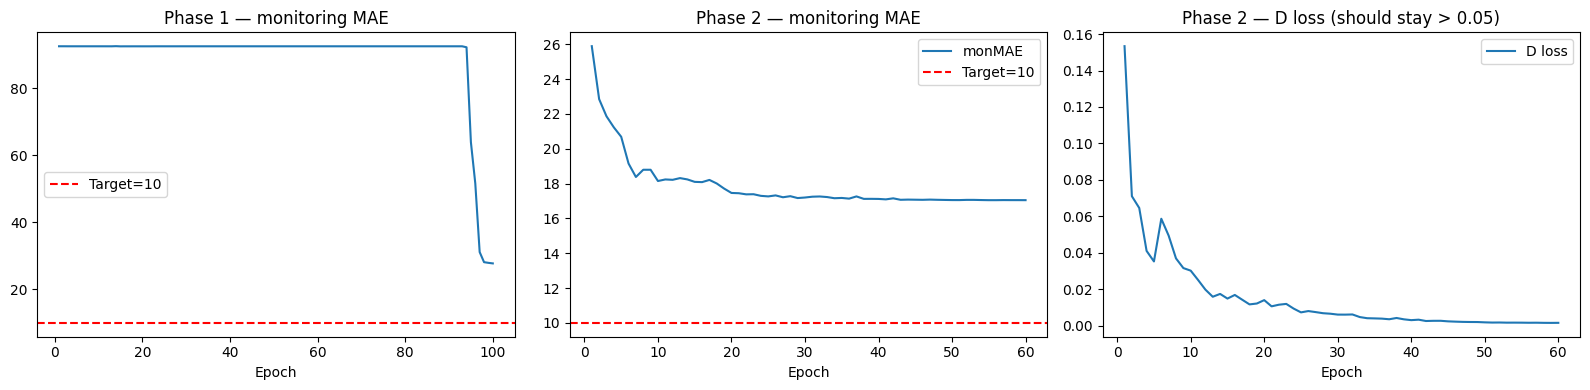

In [11]:
# Training curves — both phases
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(p1_hist['epoch'], [m for m in p1_hist['val_mae']])
axes[0].set_title('Phase 1 — monitoring MAE'); axes[0].set_xlabel('Epoch')
axes[0].axhline(y=10, color='r', linestyle='--', label='Target=10'); axes[0].legend()

axes[1].plot(p2_hist['epoch'], p2_hist['val_mae'], label='monMAE')
axes[1].set_title('Phase 2 — monitoring MAE'); axes[1].set_xlabel('Epoch')
axes[1].axhline(y=10, color='r', linestyle='--', label='Target=10'); axes[1].legend()

axes[2].plot(p2_hist['epoch'], p2_hist['d_loss'], label='D loss')
axes[2].set_title('Phase 2 — D loss (should stay > 0.05)'); axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig(CFG.output_dir / 'training_curves.png', dpi=150)
plt.show()

In [12]:
best_ckpt = CFG.gen_ckpt_p2 if best_p2_mae < best_p1_mae else CFG.gen_ckpt_p1
best_mae  = min(best_p1_mae, best_p2_mae)
G.load_state_dict(torch.load(best_ckpt, map_location=CFG.device))
G.eval()
print(f'Loaded best checkpoint (monMAE = {best_mae:.3f})')


def tta_predict(model, lr_batch):
    def run(x):
        with torch.no_grad():
            with torch.cuda.amp.autocast(enabled=CFG.amp):
                return model(x)

    preds = []

    preds.append(run(lr_batch))
    preds.append(torch.flip(run(torch.flip(lr_batch, [3])), [3]))
    preds.append(torch.flip(run(torch.flip(lr_batch, [2])), [2]))
    preds.append(torch.flip(run(torch.flip(lr_batch, [2, 3])), [2, 3]))

    lr90 = torch.rot90(lr_batch, 1, [2, 3])
    preds.append(torch.rot90(run(lr90), -1, [2, 3]))
    preds.append(torch.rot90(torch.flip(run(torch.flip(lr90, [3])), [3]), -1, [2, 3]))
    preds.append(torch.rot90(torch.flip(run(torch.flip(lr90, [2])), [2]), -1, [2, 3]))
    preds.append(torch.rot90(torch.flip(run(torch.flip(lr90, [2, 3])), [2, 3]), -1, [2, 3]))

    return torch.stack(preds).mean(dim=0)


rows = []
for lr_batch, fnames in tqdm(tst_loader, desc='Inference (8-way TTA)'):
    lr_batch = lr_batch.to(CFG.device)
    sr_batch = tta_predict(G, lr_batch)   

    
    sr_np = (sr_batch.cpu().float().clamp(0, 1).numpy() * 255.0).round().astype(np.uint8)

    for fname, img_chw in zip(fnames, sr_np):
        img_hwc = img_chw.transpose(1, 2, 0)   
        flat    = img_hwc.flatten()             
        rows.append({'Id': fname, 'Pixels': ' '.join(flat.astype(str))})

print(f'Generated {len(rows)} predictions.')

Loaded best checkpoint (monMAE = 17.045)


Inference (8-way TTA): 100%|██████████| 16/16 [00:29<00:00,  1.83s/it]

Generated 495 predictions.


In [13]:
sub_df = pd.DataFrame(rows)

assert len(sub_df) == len(tst_ds)
sample_len = len(sub_df.iloc[0]['Pixels'].split())
assert sample_len == CFG.hr_size * CFG.hr_size * CFG.n_channels, \
    f'Pixel count wrong: got {sample_len}'

sub_df = sub_df.sort_values('Id').reset_index(drop=True)
sub_path = CFG.output_dir / 'submission.csv'
sub_df.to_csv(sub_path, index=False)

print(f'Submission saved → {sub_path}')
print(sub_df.head(3).to_string())

Submission saved → /kaggle/working/submission.csv
                         Id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

Pixel range: [0, 177]  (expected 0–255)


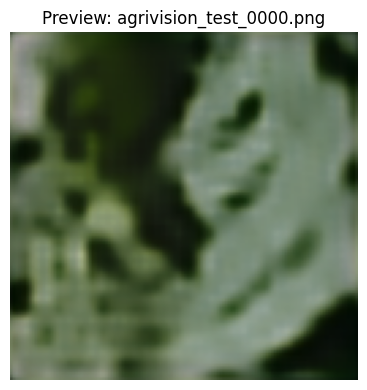

All checks passed. Ready to submit!


In [14]:
sample_pixels = np.array(sub_df.iloc[0]['Pixels'].split(), dtype=np.uint8)
print(f'Pixel range: [{sample_pixels.min()}, {sample_pixels.max()}]  (expected 0–255)')

preview = sample_pixels.reshape(CFG.hr_size, CFG.hr_size, 3)  # HWC
plt.figure(figsize=(4, 4))
plt.imshow(preview)
plt.title(f"Preview: {sub_df.iloc[0]['Id']}")
plt.axis('off'); plt.tight_layout()
plt.savefig(CFG.output_dir / 'sample_prediction.png', dpi=150)
plt.show()

print('All checks passed. Ready to submit!')